In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.stats import ks_2samp

In [2]:
dataset_names = ['Glacier','GUT.SRP056641','GUT.ERP015450','Lake','Oral','River','Soil','activatedsludge']
dataset_names = ['Estrella_full']+['Grilli.'+name for name in dataset_names]
 
dataset_labels = ['Estrela','Glacier','Gut1','Gut2','Lake','Oral','River','Soil','Sludge']

In [3]:
boxplot_low_data = []
boxplot_high_data = []

In [4]:
for dataset in dataset_names:
    with open('../out/{}/low_variance_eigenmodes.{}.dat'.format(dataset,dataset),'rb') as f:
        low_var_eigvects = pickle.load(f) #(N_species,N_vectors)
        f.close()
        print(np.shape(low_var_eigvects))
    with open('../out/{}/high_variance_eigenmodes.{}.dat'.format(dataset,dataset),'rb') as f:
        high_var_eigvects = pickle.load(f)
        f.close()

    how_many_species = np.shape(low_var_eigvects)[0]
    num_IPR = np.sum(low_var_eigvects**4,axis=0)
    den_IPR = (np.sum(low_var_eigvects**2,axis=0))**2
    low_IPRs= num_IPR/den_IPR
    num_IPR = np.sum(high_var_eigvects**4,axis=0)
    den_IPR = (np.sum(high_var_eigvects**2,axis=0))**2
    high_IPRs= num_IPR/den_IPR

    boxplot_low_data.append(1/low_IPRs/how_many_species)
    boxplot_high_data.append(1/high_IPRs/how_many_species)
    

(14, 4)
(1075, 15)
(1005, 31)
(2003, 107)
(869, 60)
(540, 45)
(2011, 94)
(561, 35)
(3177, 244)


Estrella_full pvalue 0.13333333333333333
Grilli.Glacier pvalue 0.0007739938080495355
Grilli.GUT.SRP056641 pvalue 2.8426178090151515e-06
Grilli.GUT.ERP015450 pvalue 2.566601108555504e-16
Grilli.Lake pvalue 8.768008949838019e-07
Grilli.Oral pvalue 0.0011726857365529986
Grilli.River pvalue 1.2016038250324649e-17
Grilli.Soil pvalue 2.14230301025874e-06
Grilli.activatedsludge pvalue 1.642837422383477e-05


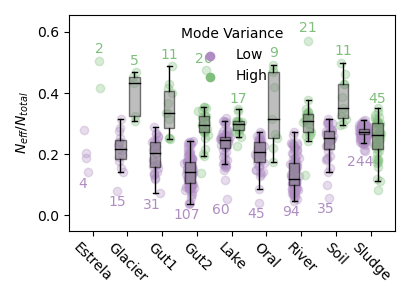

In [6]:
%matplotlib widget
fig,ax = plt.subplots(figsize=(4.1,3))
max_yval = -100
for i,dataset in enumerate(dataset_names):
    lo_dat = boxplot_low_data[i]
    hi_dat = boxplot_high_data[i]
    N_lo = len(lo_dat)
    N_hi = len(hi_dat)

    KS_result = ks_2samp(lo_dat,hi_dat,
                         alternative='two-sided')
    print(dataset,'pvalue',KS_result.pvalue)
    ''' Plot Boxplots '''
    if i>0: #aka not the estrela dataset
        bplot = ax.boxplot(list(lo_dat),
            positions=[i+0.1],
            patch_artist=True, medianprops=dict(color='k'),showfliers=False,
                           widths=0.3
            )
        
        bplot['boxes'][0].set_facecolor('tab:gray')
        bplot['boxes'][0].set_alpha(0.5)
    ax.scatter(np.random.normal(i+0.1,0.05,size=len(lo_dat)),lo_dat,
              # edgecolor='k',
               color=[175/255,141/255,195/255],alpha=0.3,
              zorder=0,
              label=None)
    ax.scatter(None,None,
              # edgecolor='k',
               color=[175/255,141/255,195/255],alpha=1,
              zorder=0,
              label='Low' if i==0 else None)
    ax.text(i,
            # np.max(lo_dat)*1.05,
            np.min(lo_dat)-0.05,
            N_lo,# if i!=0 else r'$N_R=$'+'{}'.format(N_lo),
            color=[175/255,141/255,195/255],
           ha='center')
    if i>0:
        bplot = ax.boxplot(list(hi_dat),
            positions=[i+0.5],
            patch_artist=True, medianprops=dict(color='k'),showfliers=False,
                           widths=0.3
            )
        
        bplot['boxes'][0].set_facecolor('tab:gray')
        bplot['boxes'][0].set_alpha(0.5)
    ax.scatter(np.random.normal(i+0.5,0.05,size=len(hi_dat)),hi_dat,
              # edgecolor='k',
               color=[127/255,191/255,123/255],alpha=0.3,
              zorder=0,
              label=None)
    ax.scatter(None,None,
              # edgecolor='k',
               color=[127/255,191/255,123/255],alpha=1,
              zorder=0,
              label='High' if i==0 else None)
    ax.text(i+0.5,
            np.max(hi_dat)*1.05,
            N_hi,color=[127/255,191/255,123/255],
           ha='center')
    
    if np.max(lo_dat)>max_yval: max_yval = np.max(lo_dat)
    if np.max(hi_dat)>max_yval: max_yval = np.max(hi_dat)
        

# ax.set_ylabel(r'$IPR \cdot N_{taxa}$')
ax.set_ylabel(r'$N_{eff}/N_{total}$')
ax.set_xticks(np.arange(len(dataset_names))+0.3)
ax.set_xticklabels(dataset_labels,rotation=-45,ha='center')
ax.set_ylim(bottom=-0.05,top=max_yval*1.15)
# ax.set_title('Effective number of participating species in \n low and high variance modes in natural communities')
ax.legend(loc='best',frameon=False,
          title='Mode Variance')
plt.tight_layout()
plt.savefig('IPR_low_vs_high_variance_modes.svg',format='svg',transparent=True)
plt.savefig('IPR_low_vs_high_variance_modes.png',format='png',transparent=True)

In [11]:
plt.close('all')